# MAIN2 - CNN v2 phân loại Chó / Mèo

Notebook này là bản **main2 đã chuẩn hóa lại** cho project HOCSAU trên Google Colab.

Mục tiêu:
- Dùng dataset gộp `dataset_combined_main`.
- Train CNN v2 phân loại `cats` và `dogs`.
- Đọc ảnh RGB an toàn bằng `color_mode="rgb"`.
- Có augmentation, BatchNorm, Dropout, EarlyStopping, ReduceLROnPlateau, checkpoint và resume training.
- Lưu toàn bộ output vào folder riêng, thống nhất theo kiểu output của `oxford_pet_mobilenetv2`:

```text
/content/drive/MyDrive/HOCSAU/output/main2
```

File output quan trọng cho app:
- `best_cnn_cats_dogs_main2.keras`
- `latest_cnn_cats_dogs_main2.keras`
- `final_cnn_cats_dogs_main2.keras`
- `app_model_info.json`
- `class_names.json`
- `recommended_threshold.json`
- `test_metrics.json`
- `test_predictions.csv`


In [1]:
# ============================================================
# CELL 1: KẾT NỐI GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [2]:
# ============================================================
# CELL 2: IMPORT THƯ VIỆN
# ============================================================

import os
import json
import random
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ============================================================
# CELL 3: CẤU HÌNH CHUNG
# ============================================================

SEED = 42
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20
TARGET_EPOCHS = 100
INITIAL_LEARNING_RATE = 1e-3

# Nếu muốn train lại sạch từ đầu và xóa toàn bộ output/main2 cũ, đổi thành True.
RESET_TRAINING_OUTPUT = False

# Nếu Colab bị ngắt, để True để tiếp tục từ latest model nếu có.
RESUME_TRAINING = True

# Nếu từng gặp lỗi DecodeImage/ảnh 2-channel, có thể bật True để quét và sửa ảnh.
# Nếu dataset_builder.py mới đã convert RGB rồi thì để False để tiết kiệm thời gian.
RUN_IMAGE_REPAIR = False

# Có thể bật True để kiểm tra toàn bộ dataset, nhưng sẽ khá lâu trên Google Drive.
RUN_VERIFY_DECODE = False

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("SEED:", SEED)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH_SIZE:", BATCH_SIZE)
print("TARGET_EPOCHS:", TARGET_EPOCHS)


SEED: 42
IMG_SIZE: (150, 150)
BATCH_SIZE: 32
TARGET_EPOCHS: 100


In [4]:
# ============================================================
# CELL 4: KHAI BÁO ĐƯỜNG DẪN PROJECT, DATASET, OUTPUT
# ============================================================

PROJECT_CANDIDATES = [
    Path("/content/drive/MyDrive/HOCSAU"),
    Path("/content/drive/MyDrive/Colab Notebooks/HOCSAU"),
]

PROJECT_DIR = None
for candidate in PROJECT_CANDIDATES:
    if (candidate / "data").exists() and (candidate / "output").exists():
        PROJECT_DIR = candidate
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Không tìm thấy thư mục HOCSAU. Hãy kiểm tra Drive. "
        "Notebook đang tìm ở: " + ", ".join(str(p) for p in PROJECT_CANDIDATES)
    )

APP_DIR = PROJECT_DIR / "app"
CODE_DIR = PROJECT_DIR / "code"
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_ROOT = PROJECT_DIR / "output"

DATASET_DIR = DATA_DIR / "dataset_combined_main"
TRAIN_DIR = DATASET_DIR / "training_set"
TEST_DIR = DATASET_DIR / "test_set"

# Output riêng cho bản main2 / CNN v2.
# Cấu trúc output được làm phẳng tương tự thư mục output/oxford_pet_mobilenetv2.
OUTPUT_DIR = OUTPUT_ROOT / "main2"

# Các biến dưới đây giữ để code dễ đọc. File kết quả chính nằm trực tiếp trong OUTPUT_DIR.
MODEL_DIR = OUTPUT_DIR
PLOT_DIR = OUTPUT_DIR
REPORT_DIR = OUTPUT_DIR
LOG_DIR = OUTPUT_DIR

# Các thư mục phụ chỉ dành cho backup/tensorboard/ảnh lỗi, không phải output báo cáo chính.
BACKUP_DIR = OUTPUT_DIR / "backup"
TENSORBOARD_DIR = OUTPUT_DIR / "tensorboard"
BAD_IMAGE_DIR = OUTPUT_DIR / "bad_images_tf_decode"

BEST_MODEL_PATH = OUTPUT_DIR / "best_cnn_cats_dogs_main2.keras"
LATEST_MODEL_PATH = OUTPUT_DIR / "latest_cnn_cats_dogs_main2.keras"
FINAL_MODEL_PATH = OUTPUT_DIR / "final_cnn_cats_dogs_main2.keras"

TRAINING_LOG_PATH = OUTPUT_DIR / "training_log.csv"
HISTORY_CSV_PATH = OUTPUT_DIR / "history.csv"
MODEL_SUMMARY_PATH = OUTPUT_DIR / "model_summary.txt"
CONFIG_PATH = OUTPUT_DIR / "model_config.json"
CLASS_NAMES_PATH = OUTPUT_DIR / "class_names.json"
THRESHOLD_PATH = OUTPUT_DIR / "recommended_threshold.json"
APP_MODEL_INFO_PATH = OUTPUT_DIR / "app_model_info.json"
TRAINING_INFO_PATH = OUTPUT_DIR / "training_info.json"

if RESET_TRAINING_OUTPUT and OUTPUT_DIR.exists():
    print("Đang xóa output/main2 cũ:", OUTPUT_DIR)
    shutil.rmtree(OUTPUT_DIR)

for folder in [OUTPUT_DIR, BACKUP_DIR, TENSORBOARD_DIR, BAD_IMAGE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)


PROJECT_DIR: /content/drive/MyDrive/HOCSAU
DATA_DIR: /content/drive/MyDrive/HOCSAU/data
TRAIN_DIR: /content/drive/MyDrive/HOCSAU/data/dataset_combined_main/training_set
TEST_DIR: /content/drive/MyDrive/HOCSAU/data/dataset_combined_main/test_set
OUTPUT_DIR: /content/drive/MyDrive/HOCSAU/output/main2
BEST_MODEL_PATH: /content/drive/MyDrive/HOCSAU/output/main2/best_cnn_cats_dogs_main2.keras


In [5]:
# ============================================================
# CELL 5: LƯU CONFIG CHẠY THÍ NGHIỆM
# File được lưu tên model_config.json để thống nhất với output oxford_pet_mobilenetv2.
# ============================================================

config = {
    "project_name": "HOCSAU",
    "notebook": "main2.ipynb",
    "model_name": "cnn_cat_dog_main2",
    "task": "binary_cat_dog_classification",
    "project_dir": str(PROJECT_DIR),
    "dataset_dir": str(DATASET_DIR),
    "train_dir": str(TRAIN_DIR),
    "test_dir": str(TEST_DIR),
    "output_dir": str(OUTPUT_DIR),
    "best_model_path": str(BEST_MODEL_PATH),
    "latest_model_path": str(LATEST_MODEL_PATH),
    "final_model_path": str(FINAL_MODEL_PATH),
    "seed": SEED,
    "img_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "validation_split": VALIDATION_SPLIT,
    "target_epochs": TARGET_EPOCHS,
    "initial_learning_rate": INITIAL_LEARNING_RATE,
    "reset_training_output": RESET_TRAINING_OUTPUT,
    "resume_training": RESUME_TRAINING,
    "run_image_repair": RUN_IMAGE_REPAIR,
    "run_verify_decode": RUN_VERIFY_DECODE,
    "output_style": "flat_like_oxford_pet_mobilenetv2",
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

print("Đã lưu model_config:", CONFIG_PATH)


Đã lưu model_config: /content/drive/MyDrive/HOCSAU/output/main2/model_config.json


/content/drive/MyDrive/HOCSAU/data/dataset_combined_main/training_set/cats -> True
/content/drive/MyDrive/HOCSAU/data/dataset_combined_main/training_set/dogs -> True
/content/drive/MyDrive/HOCSAU/data/dataset_combined_main/test_set/cats -> True
/content/drive/MyDrive/HOCSAU/data/dataset_combined_main/test_set/dogs -> True


,split,class,path,count
0,train,cats,/content/drive/MyDrive/HOCSAU/data/dataset_com...,8000
1,train,dogs,/content/drive/MyDrive/HOCSAU/data/dataset_com...,8000
2,test,cats,/content/drive/MyDrive/HOCSAU/data/dataset_com...,2000
3,test,dogs,/content/drive/MyDrive/HOCSAU/data/dataset_com...,2000


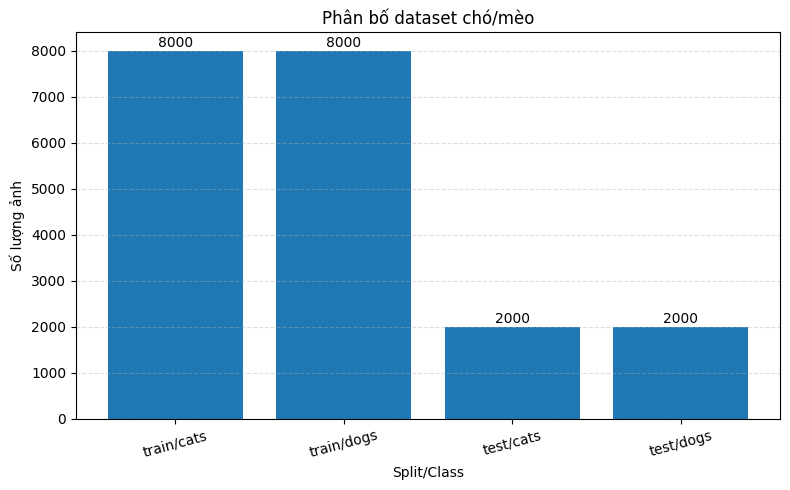

Tổng train: 16000
Tổng test: 4000
Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/dataset_counts.csv
Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/eda_summary.json
Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/eda_class_distribution.png


In [6]:
# ============================================================
# CELL 6: KIỂM TRA DATASET ĐẦU VÀO + EDA PHÂN BỐ LỚP
# ============================================================

VALID_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

required_paths = [
    TRAIN_DIR / "cats",
    TRAIN_DIR / "dogs",
    TEST_DIR / "cats",
    TEST_DIR / "dogs",
]

missing_paths = []
for path in required_paths:
    print(path, "->", path.exists())
    if not path.exists():
        missing_paths.append(path)

if missing_paths:
    raise FileNotFoundError(
        "Dataset chưa đủ cấu trúc training_set/test_set/cats/dogs. "
        "Hãy chạy dataset_builder.py trước. Thiếu: " + ", ".join(str(p) for p in missing_paths)
    )

def count_images(folder: Path) -> int:
    return len([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    ])

count_df = pd.DataFrame([
    {"split": "train", "class": "cats", "path": str(TRAIN_DIR / "cats"), "count": count_images(TRAIN_DIR / "cats")},
    {"split": "train", "class": "dogs", "path": str(TRAIN_DIR / "dogs"), "count": count_images(TRAIN_DIR / "dogs")},
    {"split": "test", "class": "cats", "path": str(TEST_DIR / "cats"), "count": count_images(TEST_DIR / "cats")},
    {"split": "test", "class": "dogs", "path": str(TEST_DIR / "dogs"), "count": count_images(TEST_DIR / "dogs")},
])

display(count_df)

dataset_counts_path = OUTPUT_DIR / "dataset_counts.csv"
count_df.to_csv(dataset_counts_path, index=False, encoding="utf-8-sig")

eda_summary = {
    "dataset_dir": str(DATASET_DIR),
    "train_cats": int(count_df[(count_df["split"] == "train") & (count_df["class"] == "cats")]["count"].iloc[0]),
    "train_dogs": int(count_df[(count_df["split"] == "train") & (count_df["class"] == "dogs")]["count"].iloc[0]),
    "test_cats": int(count_df[(count_df["split"] == "test") & (count_df["class"] == "cats")]["count"].iloc[0]),
    "test_dogs": int(count_df[(count_df["split"] == "test") & (count_df["class"] == "dogs")]["count"].iloc[0]),
    "total_train": int(count_df[count_df["split"] == "train"]["count"].sum()),
    "total_test": int(count_df[count_df["split"] == "test"]["count"].sum()),
    "total_all": int(count_df["count"].sum()),
}

with open(OUTPUT_DIR / "eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(eda_summary, f, ensure_ascii=False, indent=2)

plt.figure(figsize=(8, 5))
x_labels = count_df["split"] + "/" + count_df["class"]
plt.bar(x_labels, count_df["count"])
for idx, value in enumerate(count_df["count"]):
    plt.text(idx, value + max(count_df["count"]) * 0.01, str(value), ha="center")
plt.title("Phân bố dataset chó/mèo")
plt.xlabel("Split/Class")
plt.ylabel("Số lượng ảnh")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=15)
plt.tight_layout()
eda_plot_path = OUTPUT_DIR / "eda_class_distribution.png"
plt.savefig(eda_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Tổng train:", eda_summary["total_train"])
print("Tổng test:", eda_summary["total_test"])
print("Đã lưu:", dataset_counts_path)
print("Đã lưu:", OUTPUT_DIR / "eda_summary.json")
print("Đã lưu:", eda_plot_path)


In [7]:
# ============================================================
# CELL 7: SỬA ẢNH KHÔNG DECODE ĐƯỢC / ẢNH KHÁC RGB 3 KÊNH
# Ghi chú:
# - Mặc định RUN_IMAGE_REPAIR=False để tiết kiệm thời gian.
# - Nếu model.fit báo lỗi DecodeImage, bật True rồi chạy lại cell này.
# ============================================================

SCAN_DIRS = [
    TRAIN_DIR / "cats",
    TRAIN_DIR / "dogs",
    TEST_DIR / "cats",
    TEST_DIR / "dogs",
]


def get_all_image_paths(scan_dirs):
    paths = []
    for folder in scan_dirs:
        folder = Path(folder)
        if folder.exists():
            paths.extend([
                p for p in folder.rglob("*")
                if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
            ])
    return paths


def tf_decode_check(image_path):
    try:
        raw = tf.io.read_file(str(image_path))
        img = tf.io.decode_image(raw, channels=0, expand_animations=False)
        if img.shape.rank == 3 and img.shape[-1] is not None:
            channels = int(img.shape[-1])
        else:
            channels = int(tf.shape(img)[-1].numpy())
        return True, channels, ""
    except Exception as e:
        return False, None, str(e).split("\n")[0]


def save_as_rgb_inplace(image_path):
    image_path = Path(image_path)
    tmp_path = image_path.with_name(image_path.stem + "_tmp_rgb" + image_path.suffix)
    try:
        with Image.open(image_path) as img:
            old_mode = img.mode
            old_bands = len(img.getbands())
            old_format = img.format
            rgb_img = img.convert("RGB")

            suffix = image_path.suffix.lower()
            save_kwargs = {}
            if suffix in [".jpg", ".jpeg"]:
                save_format = "JPEG"
                save_kwargs = {"quality": 95}
            elif suffix == ".png":
                save_format = "PNG"
            elif suffix == ".bmp":
                save_format = "BMP"
            elif suffix == ".webp":
                save_format = "WEBP"
                save_kwargs = {"quality": 95}
            else:
                save_format = old_format if old_format else "JPEG"

            rgb_img.save(tmp_path, format=save_format, **save_kwargs)

        os.replace(tmp_path, image_path)
        return True, old_mode, old_bands, ""
    except Exception as e:
        if tmp_path.exists():
            tmp_path.unlink()
        return False, None, None, str(e)


if RUN_IMAGE_REPAIR:
    all_paths = get_all_image_paths(SCAN_DIRS)
    print("Tổng số ảnh cần kiểm tra:", len(all_paths))

    log_records = []
    fixed_count = 0
    moved_bad_count = 0

    for idx, path in enumerate(all_paths, start=1):
        if idx % 1000 == 0:
            print(f"Đã kiểm tra {idx}/{len(all_paths)} ảnh...")

        ok, channels, err = tf_decode_check(path)

        if (not ok) or (channels != 3):
            fixed, old_mode, old_bands, fix_err = save_as_rgb_inplace(path)
            ok_after, channels_after, err_after = tf_decode_check(path)

            if fixed and ok_after and channels_after == 3:
                fixed_count += 1
                log_records.append({
                    "path": str(path),
                    "status": "fixed_to_rgb",
                    "old_channels": channels,
                    "new_channels": channels_after,
                    "old_mode": old_mode,
                    "old_bands": old_bands,
                    "decode_error_before": err,
                    "fix_error": "",
                })
            else:
                bad_target = BAD_IMAGE_DIR / str(path).replace("/", "__")
                shutil.move(str(path), str(bad_target))
                moved_bad_count += 1
                log_records.append({
                    "path": str(path),
                    "status": "moved_bad_image",
                    "old_channels": channels,
                    "new_channels": channels_after,
                    "old_mode": old_mode,
                    "old_bands": old_bands,
                    "decode_error_before": err,
                    "fix_error": fix_err if fix_err else err_after,
                })

    log_df = pd.DataFrame(log_records)
    log_path = LOG_DIR / "tf_decode_image_fix_log.csv"
    log_df.to_csv(log_path, index=False, encoding="utf-8-sig")

    print("Hoàn tất kiểm tra/sửa ảnh.")
    print("Số ảnh đã chuyển về RGB:", fixed_count)
    print("Số ảnh lỗi nặng đã chuyển ra ngoài dataset:", moved_bad_count)
    print("Log lưu tại:", log_path)

    if len(log_df) > 0:
        display(log_df.head(20))
    else:
        print("Không phát hiện ảnh lỗi hoặc ảnh khác RGB.")
else:
    print("Bỏ qua bước sửa ảnh vì RUN_IMAGE_REPAIR=False.")


Bỏ qua bước sửa ảnh vì RUN_IMAGE_REPAIR=False.


In [8]:
# ============================================================
# CELL 8: ĐỌC DATASET BẰNG image_dataset_from_directory
# Đồng thời lưu train_split.csv, val_split.csv, test_split.csv
# để thống nhất với output oxford_pet_mobilenetv2.
# ============================================================

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=True,
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=True,
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=False,
)

class_names = train_ds_raw.class_names
class_names_vi = ["Mèo" if name == "cats" else "Chó" for name in class_names]

class_info = {
    "class_names": class_names,
    "class_names_vi": class_names_vi,
    "label_mode": "binary",
    "class_mapping": {name: idx for idx, name in enumerate(class_names)},
    "positive_class": "dogs",
    "positive_class_index": class_names.index("dogs") if "dogs" in class_names else 1,
    "note": "Với binary sigmoid: output gần 0 là cats, output gần 1 là dogs.",
}

# class_names.json lưu dạng list để thống nhất với output oxford_pet_mobilenetv2.
with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

with open(OUTPUT_DIR / "class_info.json", "w", encoding="utf-8") as f:
    json.dump(class_info, f, ensure_ascii=False, indent=2)

def infer_class_from_path(path):
    parent = Path(path).parent.name
    return parent

def save_split_file(ds, split_name, output_path):
    file_paths = getattr(ds, "file_paths", [])
    records = []
    for path in file_paths:
        class_name = infer_class_from_path(path)
        label_index = class_names.index(class_name) if class_name in class_names else None
        label_vi = class_names_vi[label_index] if label_index is not None else None
        records.append({
            "split": split_name,
            "file_path": str(path),
            "class": class_name,
            "class_vi": label_vi,
            "label_index": label_index,
        })
    split_df = pd.DataFrame(records)
    split_df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Đã lưu {split_name}: {output_path} ({len(split_df)} ảnh)")
    return split_df

train_split_df = save_split_file(train_ds_raw, "train", OUTPUT_DIR / "train_split.csv")
val_split_df = save_split_file(val_ds_raw, "val", OUTPUT_DIR / "val_split.csv")
test_split_df = save_split_file(test_ds_raw, "test", OUTPUT_DIR / "test_split.csv")

print("class_names:", class_names)
print("class_names_vi:", class_names_vi)
print("Đã lưu:", CLASS_NAMES_PATH)

for images, labels in train_ds_raw.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Pixel min/max:", float(tf.reduce_min(images)), float(tf.reduce_max(images)))


Found 16000 files belonging to 2 classes.
Using 12800 files for training.
Found 16000 files belonging to 2 classes.
Using 3200 files for validation.
Found 4000 files belonging to 2 classes.
Đã lưu train: /content/drive/MyDrive/HOCSAU/output/main2/train_split.csv (12800 ảnh)
Đã lưu val: /content/drive/MyDrive/HOCSAU/output/main2/val_split.csv (3200 ảnh)
Đã lưu test: /content/drive/MyDrive/HOCSAU/output/main2/test_split.csv (4000 ảnh)
class_names: ['cats', 'dogs']
class_names_vi: ['Mèo', 'Chó']
Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/class_names.json
Batch image shape: (32, 150, 150, 3)
Batch label shape: (32, 1)
Image dtype: <dtype: 'float32'>
Pixel min/max: 0.0 255.0


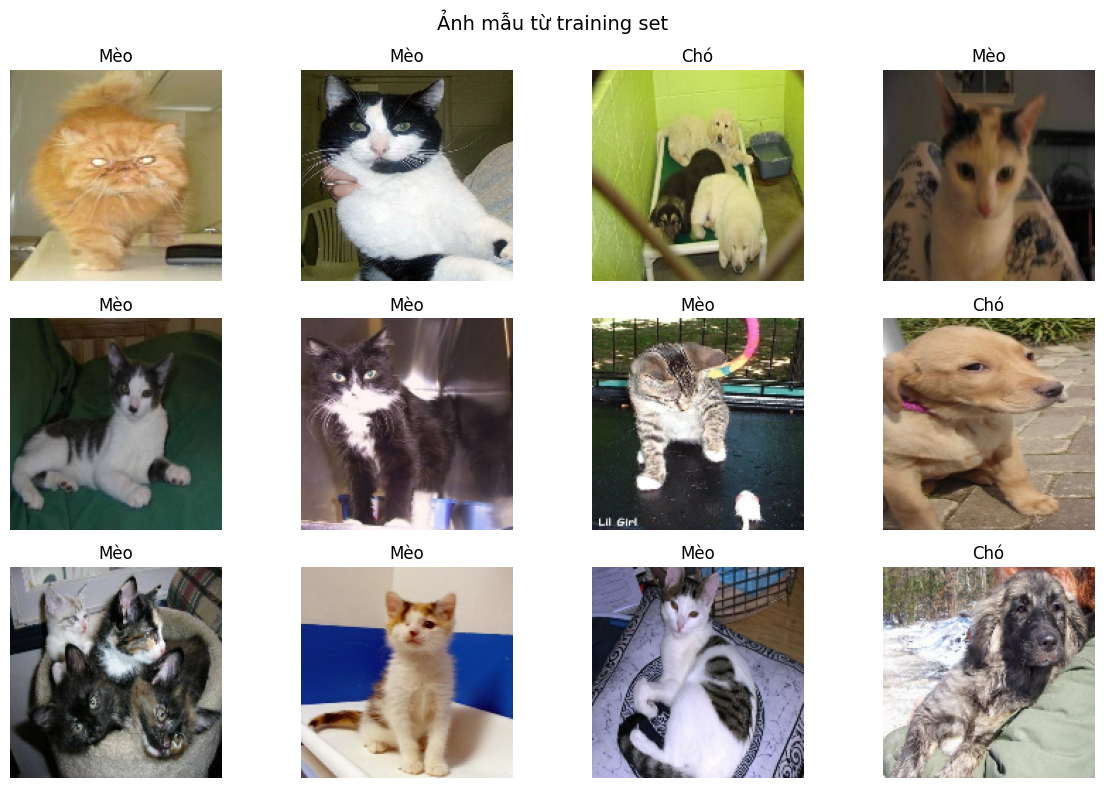

Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/eda_sample_images.png


In [9]:
# ============================================================
# CELL 9: VISUALIZE ẢNH MẪU TRONG TRAINING SET
# ============================================================

plt.figure(figsize=(12, 8))

for images, labels in train_ds_raw.take(1):
    max_images = min(12, images.shape[0])
    for i in range(max_images):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = int(labels[i].numpy()[0])
        plt.title(class_names_vi[label_idx])
        plt.axis("off")

plt.suptitle("Ảnh mẫu từ training set", fontsize=14)
plt.tight_layout()
sample_plot_path = PLOT_DIR / "eda_sample_images.png"
plt.savefig(sample_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu:", sample_plot_path)


In [10]:
# ============================================================
# CELL 10: KIỂM TRA DATASET CÓ DECODE HẾT ĐƯỢC KHÔNG
# Chạy trước model.fit để bắt lỗi ảnh sớm.
# ============================================================


def verify_dataset(ds, name):
    total = 0
    for images, labels in ds:
        if images.shape[-1] != 3:
            raise ValueError(f"{name}: ảnh không phải RGB 3 kênh, shape={images.shape}")
        total += int(images.shape[0])
    print(f"{name}: decode OK, tổng ảnh đọc được = {total}")
    return total

if RUN_VERIFY_DECODE:
    verify_counts = {
        "train": verify_dataset(train_ds_raw, "train_ds_raw"),
        "val": verify_dataset(val_ds_raw, "val_ds_raw"),
        "test": verify_dataset(test_ds_raw, "test_ds_raw"),
    }
    with open(REPORT_DIR / "verify_decode_counts.json", "w", encoding="utf-8") as f:
        json.dump(verify_counts, f, ensure_ascii=False, indent=2)
else:
    print("Bỏ qua verify decode vì RUN_VERIFY_DECODE=False.")


Bỏ qua verify decode vì RUN_VERIFY_DECODE=False.


In [11]:
# ============================================================
# CELL 11: TỐI ƯU PIPELINE DATASET
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

# Không cache toàn bộ dataset vào RAM để tránh đầy bộ nhớ Colab Free.
train_ds = train_ds_raw.prefetch(AUTOTUNE)
val_ds = val_ds_raw.prefetch(AUTOTUNE)
test_ds = test_ds_raw.prefetch(AUTOTUNE)

print("Đã tạo train_ds / val_ds / test_ds với prefetch(AUTOTUNE).")


Đã tạo train_ds / val_ds / test_ds với prefetch(AUTOTUNE).


In [12]:
# ============================================================
# CELL 12: XÂY DỰNG MODEL CNN v2
# Kiến trúc:
# - Data augmentation trong model
# - Rescaling(1./255) trong model
# - Conv2D + BatchNormalization + ReLU + MaxPooling
# - GlobalAveragePooling2D để giảm overfitting so với Flatten
# - Dense + Dropout
# - Sigmoid output cho binary classification
# ============================================================


def conv_block(x, filters, dropout_rate=0.0, block_name="block"):
    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(1e-4),
        name=f"{block_name}_conv1",
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.ReLU(name=f"{block_name}_relu1")(x)

    x = layers.Conv2D(
        filters,
        3,
        padding="same",
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(1e-4),
        name=f"{block_name}_conv2",
    )(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)
    x = layers.ReLU(name=f"{block_name}_relu2")(x)

    x = layers.MaxPooling2D(name=f"{block_name}_pool")(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate, name=f"{block_name}_dropout")(x)

    return x


def build_cnn_v2(input_shape=(150, 150, 3)):
    inputs = keras.Input(shape=input_shape, name="input_image")

    x = layers.RandomFlip("horizontal", seed=SEED, name="aug_random_flip")(inputs)
    x = layers.RandomRotation(0.08, seed=SEED, name="aug_random_rotation")(x)
    x = layers.RandomZoom(0.10, seed=SEED, name="aug_random_zoom")(x)
    x = layers.RandomTranslation(0.05, 0.05, seed=SEED, name="aug_random_translation")(x)
    x = layers.RandomContrast(0.10, seed=SEED, name="aug_random_contrast")(x)

    x = layers.Rescaling(1.0 / 255.0, name="rescaling_1_255")(x)

    x = conv_block(x, 32, dropout_rate=0.00, block_name="block1")
    x = conv_block(x, 64, dropout_rate=0.10, block_name="block2")
    x = conv_block(x, 128, dropout_rate=0.15, block_name="block3")
    x = conv_block(x, 256, dropout_rate=0.20, block_name="block4")

    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)

    x = layers.Dense(
        256,
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_256",
    )(x)
    x = layers.BatchNormalization(name="dense_256_bn")(x)
    x = layers.ReLU(name="dense_256_relu")(x)
    x = layers.Dropout(0.40, name="dense_256_dropout")(x)

    x = layers.Dense(
        64,
        kernel_initializer="he_normal",
        kernel_regularizer=regularizers.l2(1e-4),
        name="dense_64",
    )(x)
    x = layers.ReLU(name="dense_64_relu")(x)
    x = layers.Dropout(0.20, name="dense_64_dropout")(x)

    outputs = layers.Dense(1, activation="sigmoid", name="prob_dog")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="cnn_cat_dog_v2")
    return model


def compile_model(model, learning_rate=INITIAL_LEARNING_RATE):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model


if RESUME_TRAINING and LATEST_MODEL_PATH.exists():
    print("Tìm thấy latest model. Load để tiếp tục train:", LATEST_MODEL_PATH)
    model = keras.models.load_model(LATEST_MODEL_PATH)
else:
    print("Chưa có latest model. Tạo model CNN v2 mới.")
    model = build_cnn_v2(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    model = compile_model(model)

model.summary()

with open(MODEL_SUMMARY_PATH, "w", encoding="utf-8") as f:
    model.summary(print_fn=lambda line: f.write(line + "\n"))

print("Đã lưu model summary:", MODEL_SUMMARY_PATH)


Chưa có latest model. Tạo model CNN v2 mới.


Model: "cnn_cat_dog_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_random_flip (RandomFlip)    │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_random_rotation             │ (None, 150, 150, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_random_zoom (RandomZoom)    │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_random_translation          │ (None, 150, 150, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_random_contrast             │ (None, 150, 150, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1_255 (Rescaling)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 150, 150, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (ReLU)             │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 150, 150, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (ReLU)             │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 75, 75, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (ReLU)             │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 75, 75, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (ReLU)             │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,259,425 (4.80 MB)

 Trainable params: 1,256,993 (4.80 MB)

 Non-trainable params: 2,432 (9.50 KB)

Đã lưu model summary: /content/drive/MyDrive/HOCSAU/output/main2/model_summary.txt


In [13]:
# ============================================================
# CELL 13: CALLBACKS - CHECKPOINT, EARLY STOP, REDUCE LR, LOG
# ============================================================


def get_start_epoch(log_path: Path) -> int:
    if log_path.exists():
        try:
            log_df = pd.read_csv(log_path)
            return int(len(log_df))
        except Exception:
            return 0
    return 0

start_epoch = get_start_epoch(TRAINING_LOG_PATH) if (RESUME_TRAINING and LATEST_MODEL_PATH.exists()) else 0

print("Epoch đã train:", start_epoch)
print("TARGET_EPOCHS:", TARGET_EPOCHS)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(LATEST_MODEL_PATH),
        save_best_only=False,
        verbose=0,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=12,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(
        filename=str(TRAINING_LOG_PATH),
        append=start_epoch > 0,
    ),
    keras.callbacks.BackupAndRestore(
        backup_dir=str(BACKUP_DIR),
    ),
    keras.callbacks.TensorBoard(
        log_dir=str(TENSORBOARD_DIR),
    ),
    keras.callbacks.TerminateOnNaN(),
]

print("Callbacks đã sẵn sàng.")
print("Training log:", TRAINING_LOG_PATH)


Epoch đã train: 0
TARGET_EPOCHS: 100
Callbacks đã sẵn sàng.
Training log: /content/drive/MyDrive/HOCSAU/output/main2/training_log.csv


In [14]:
# ============================================================
# CELL 14: TRAIN MODEL CNN v2
# ============================================================

start_time = time.time()

if start_epoch >= TARGET_EPOCHS:
    print("Model đã train đủ TARGET_EPOCHS. Bỏ qua fit.")
    history = None
else:
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=TARGET_EPOCHS,
        initial_epoch=start_epoch,
        callbacks=callbacks,
        verbose=1,
    )

elapsed = time.time() - start_time
print(f"Thời gian train cell này: {elapsed/60:.2f} phút")

# Lưu final model sau lần train hiện tại.
model.save(FINAL_MODEL_PATH)
print("Đã lưu final model:", FINAL_MODEL_PATH)

# Nếu vì lý do nào đó chưa có best model, lưu model hiện tại làm best.
if not BEST_MODEL_PATH.exists():
    model.save(BEST_MODEL_PATH)
    print("Chưa có best model nên đã lưu model hiện tại:", BEST_MODEL_PATH)


Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5678 - auc: 0.5968 - loss: 0.9662 - precision: 0.5725 - recall: 0.5505
Epoch 1: val_auc improved from None to 0.67428, saving model to /content/drive/MyDrive/HOCSAU/output/main2/best_cnn_cats_dogs_main2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/HOCSAU/output/main2/best_cnn_cats_dogs_main2.keras
400/400 ━━━━━━━━━━━━━━━━━━━━ 1559s 4s/step - accuracy: 0.5979 - auc: 0.6368 - loss: 0.9241 - precision: 0.6011 - recall: 0.5781 - val_accuracy: 0.6003 - val_auc: 0.6743 - val_loss: 0.8776 - val_precision: 0.5733 - val_recall: 0.8037 - learning_rate: 0.0010
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.6480 - auc: 0.6934 - loss: 0.8522 - precision: 0.6616 - recall: 0.6118
Epoch 2: val_auc improved from 0.67428 to 0.73052, saving model to /content/drive/MyDrive/HOCSAU/output/main2/best_cnn_cats_dogs_main2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/HOCSAU/output/main2/

,epoch,accuracy,auc,learning_rate,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
61,61,0.986016,0.999002,0.000031,0.107496,0.985007,0.987011,0.951875,0.991464,0.197207,0.966069,0.937267
62,62,0.985234,0.998983,0.000031,0.107481,0.983924,0.986541,0.957500,0.991387,0.191140,0.958333,0.957143
63,63,0.986484,0.999113,0.000031,0.104793,0.986997,0.985915,0.955312,0.991345,0.195042,0.955307,0.955901
64,64,0.986094,0.998937,0.000016,0.106774,0.985161,0.987011,0.954687,0.991861,0.193345,0.951882,0.958385
65,65,0.988828,0.999142,0.000016,0.101375,0.988276,0.989358,0.955625,0.991184,0.196710,0.963970,0.947205


Đã lưu history: /content/drive/MyDrive/HOCSAU/output/main2/history.csv


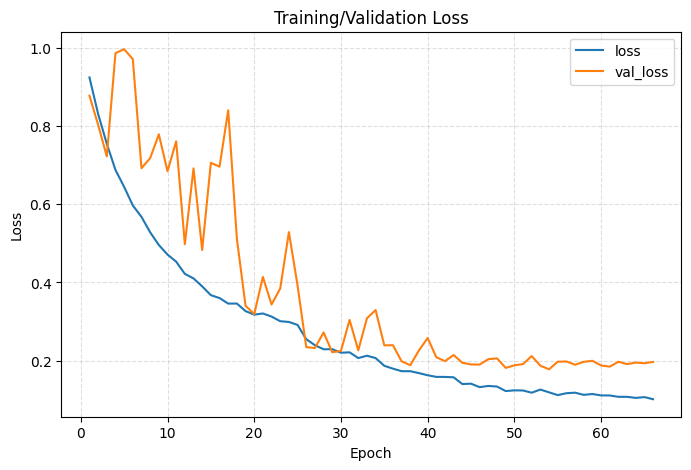

Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/loss_curve.png


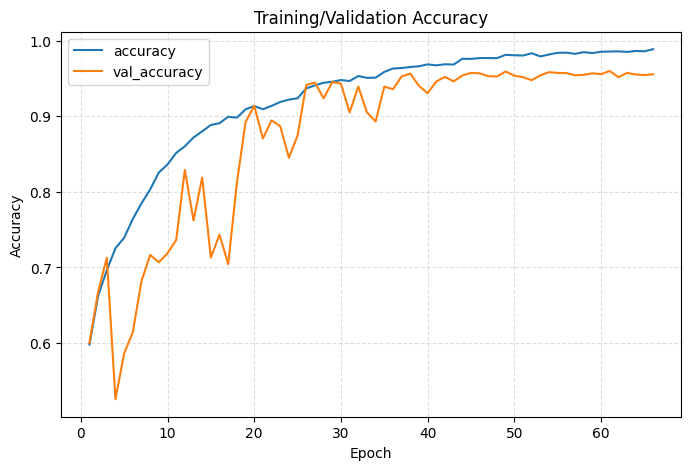

Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/accuracy_curve.png


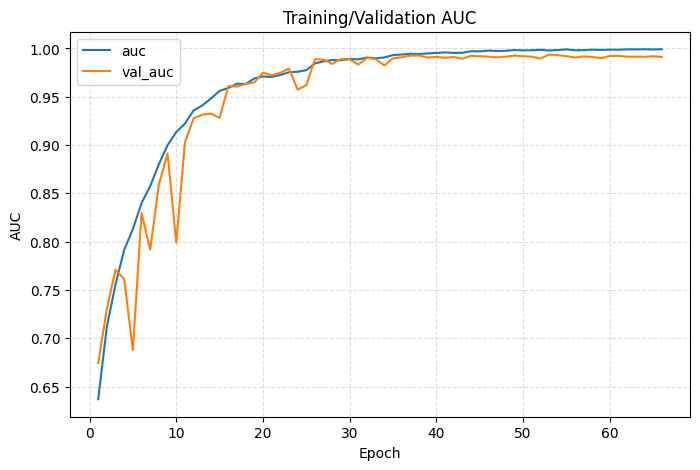

Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/auc_curve.png


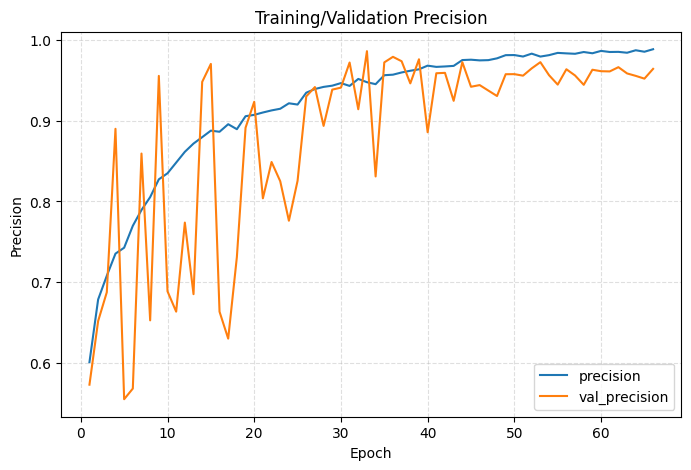

Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/precision_curve.png


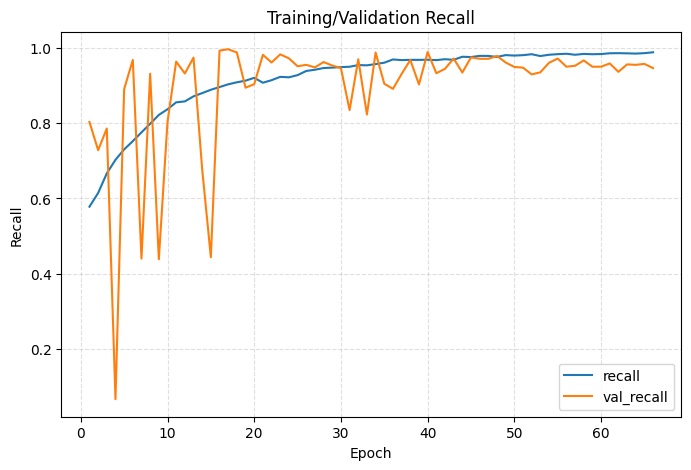

Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/recall_curve.png


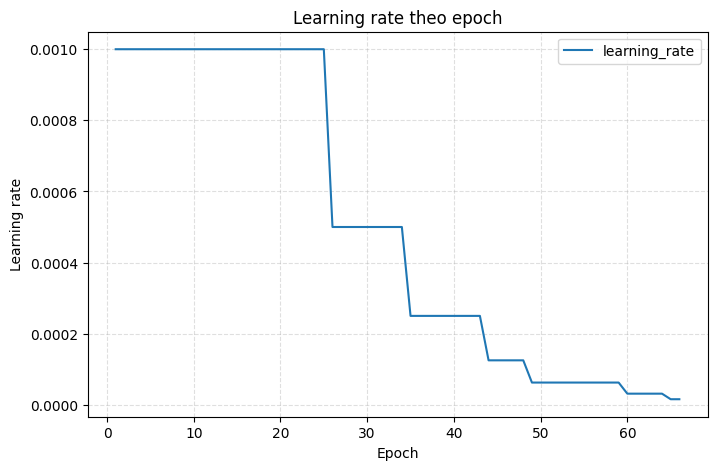

Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/learning_rate_curve.png


In [15]:
# ============================================================
# CELL 15: ĐỌC TRAINING HISTORY VÀ VẼ BIỂU ĐỒ
# File output đặt giống style oxford_pet_mobilenetv2: history.csv, accuracy_curve.png, loss_curve.png.
# ============================================================

if TRAINING_LOG_PATH.exists():
    history_df = pd.read_csv(TRAINING_LOG_PATH)
    history_df.to_csv(HISTORY_CSV_PATH, index=False, encoding="utf-8-sig")
    display(history_df.tail())
    print("Đã lưu history:", HISTORY_CSV_PATH)
else:
    raise FileNotFoundError("Không tìm thấy training log: " + str(TRAINING_LOG_PATH))


def plot_history_metric(history_df, metric, ylabel, output_name, title=None):
    plt.figure(figsize=(8, 5))
    if metric in history_df.columns:
        plt.plot(history_df["epoch"] + 1, history_df[metric], label=metric)
    val_metric = "val_" + metric
    if val_metric in history_df.columns:
        plt.plot(history_df["epoch"] + 1, history_df[val_metric], label=val_metric)
    plt.title(title if title else output_name.replace("_", " ").replace(".png", ""))
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    output_path = OUTPUT_DIR / output_name
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Đã lưu:", output_path)

plot_history_metric(history_df, "loss", "Loss", "loss_curve.png", "Training/Validation Loss")
plot_history_metric(history_df, "accuracy", "Accuracy", "accuracy_curve.png", "Training/Validation Accuracy")
plot_history_metric(history_df, "auc", "AUC", "auc_curve.png", "Training/Validation AUC")
plot_history_metric(history_df, "precision", "Precision", "precision_curve.png", "Training/Validation Precision")
plot_history_metric(history_df, "recall", "Recall", "recall_curve.png", "Training/Validation Recall")

if "learning_rate" in history_df.columns:
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"] + 1, history_df["learning_rate"], label="learning_rate")
    plt.title("Learning rate theo epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    lr_plot_path = OUTPUT_DIR / "learning_rate_curve.png"
    plt.savefig(lr_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Đã lưu:", lr_plot_path)


In [16]:
# ============================================================
# CELL 16: LOAD BEST MODEL VÀ ĐÁNH GIÁ NHANH TRÊN TEST SET
# ============================================================

best_model = keras.models.load_model(BEST_MODEL_PATH)

print("Best model:", BEST_MODEL_PATH)

test_eval = best_model.evaluate(test_ds, return_dict=True, verbose=1)

print("Kết quả evaluate trên test set:")
for key, value in test_eval.items():
    print(f"{key}: {value:.6f}")

with open(OUTPUT_DIR / "test_evaluate_metrics.json", "w", encoding="utf-8") as f:
    json.dump({k: float(v) for k, v in test_eval.items()}, f, ensure_ascii=False, indent=2)

pd.DataFrame([test_eval]).to_csv(OUTPUT_DIR / "test_evaluate_metrics.csv", index=False, encoding="utf-8-sig")

print("Đã lưu test_evaluate_metrics.json/csv.")


Best model: /content/drive/MyDrive/HOCSAU/output/main2/best_cnn_cats_dogs_main2.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 686s 5s/step - accuracy: 0.9553 - auc: 0.9918 - loss: 0.1973 - precision: 0.9705 - recall: 0.9390
Kết quả evaluate trên test set:
accuracy: 0.955250
auc: 0.991810
loss: 0.197341
precision: 0.970543
recall: 0.939000
Đã lưu test_evaluate_metrics.json/csv.


Metrics threshold=0.50:
threshold: 0.500000
accuracy: 0.955250
precision: 0.970543
recall: 0.939000
f1: 0.954511
auc: 0.992786

Classification report threshold=0.50:
              precision    recall  f1-score   support

        cats       0.94      0.97      0.96      2000
        dogs       0.97      0.94      0.95      2000

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



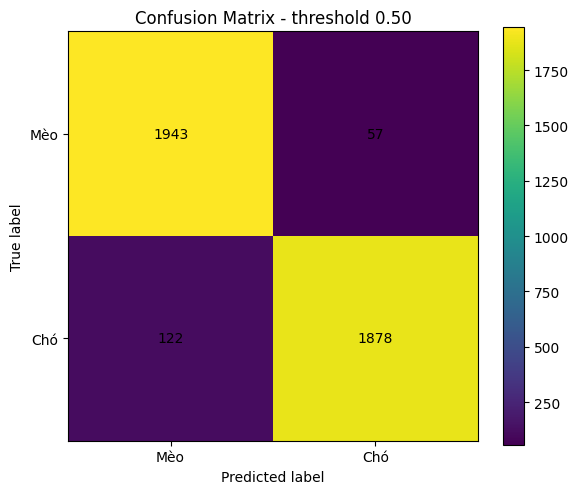

Đã lưu confusion matrix: /content/drive/MyDrive/HOCSAU/output/main2/confusion_matrix_threshold_0_50.png


In [17]:
# ============================================================
# CELL 17: DỰ ĐOÁN TEST SET, CONFUSION MATRIX, CLASSIFICATION REPORT
# ============================================================


def collect_predictions(model, ds):
    y_true_list = []
    y_prob_list = []

    for images, labels in ds:
        probs = model.predict(images, verbose=0).reshape(-1)
        y_prob_list.append(probs)
        y_true_list.append(labels.numpy().reshape(-1))

    y_true = np.concatenate(y_true_list).astype(int)
    y_prob = np.concatenate(y_prob_list).astype(float)
    return y_true, y_prob


y_test_true, y_test_prob = collect_predictions(best_model, test_ds_raw)
y_test_pred_05 = (y_test_prob >= 0.50).astype(int)

test_file_paths = getattr(test_ds_raw, "file_paths", [None] * len(y_test_true))

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "auc": float(roc_auc_score(y_true, y_prob)),
    }
    return metrics, y_pred

metrics_05, y_test_pred_05 = compute_binary_metrics(y_test_true, y_test_prob, threshold=0.5)

print("Metrics threshold=0.50:")
for key, value in metrics_05.items():
    print(f"{key}: {value:.6f}")

with open(OUTPUT_DIR / "test_metrics_threshold_0_50.json", "w", encoding="utf-8") as f:
    json.dump(metrics_05, f, ensure_ascii=False, indent=2)

report_dict = classification_report(
    y_test_true,
    y_test_pred_05,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
report_text = classification_report(
    y_test_true,
    y_test_pred_05,
    target_names=class_names,
    zero_division=0,
)

with open(OUTPUT_DIR / "classification_report_threshold_0_50.json", "w", encoding="utf-8") as f:
    json.dump(report_dict, f, ensure_ascii=False, indent=2)
with open(OUTPUT_DIR / "classification_report_threshold_0_50.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print("\nClassification report threshold=0.50:")
print(report_text)

cm = confusion_matrix(y_test_true, y_test_pred_05)
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
    OUTPUT_DIR / "confusion_matrix_threshold_0_50.csv",
    encoding="utf-8-sig",
)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - threshold 0.50")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(len(class_names)), class_names_vi)
plt.yticks(range(len(class_names)), class_names_vi)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.colorbar()
plt.tight_layout()
cm_plot_path = OUTPUT_DIR / "confusion_matrix_threshold_0_50.png"
plt.savefig(cm_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu confusion matrix:", cm_plot_path)


In [18]:
# ============================================================
# CELL 18: TỐI ƯU THRESHOLD TRÊN VALIDATION SET
# Không chọn threshold bằng test set để tránh rò rỉ đánh giá.
# ============================================================

y_val_true, y_val_prob = collect_predictions(best_model, val_ds_raw)

threshold_records = []
for threshold in np.arange(0.30, 0.701, 0.01):
    metrics, _ = compute_binary_metrics(y_val_true, y_val_prob, threshold=threshold)
    threshold_records.append(metrics)

threshold_df = pd.DataFrame(threshold_records)
threshold_df.to_csv(OUTPUT_DIR / "threshold_search_validation.csv", index=False, encoding="utf-8-sig")

display(threshold_df.sort_values("f1", ascending=False).head(10))
display(threshold_df.sort_values("accuracy", ascending=False).head(10))

best_f1_row = threshold_df.sort_values(["f1", "accuracy", "auc"], ascending=False).iloc[0].to_dict()
best_acc_row = threshold_df.sort_values(["accuracy", "f1", "auc"], ascending=False).iloc[0].to_dict()
recommended_threshold = float(best_f1_row["threshold"])

threshold_info = {
    "recommended_threshold": recommended_threshold,
    "selection_metric": "validation_f1",
    "best_by_f1": {k: float(v) for k, v in best_f1_row.items()},
    "best_by_accuracy": {k: float(v) for k, v in best_acc_row.items()},
    "note": "Threshold được chọn trên validation set, không chọn bằng test set.",
}

with open(THRESHOLD_PATH, "w", encoding="utf-8") as f:
    json.dump(threshold_info, f, ensure_ascii=False, indent=2)

print("Recommended threshold:", recommended_threshold)
print("Đã lưu:", THRESHOLD_PATH)


,threshold,accuracy,precision,recall,f1,auc
5,0.35,0.958438,0.967701,0.949068,0.958294,0.99411
3,0.33,0.958125,0.965909,0.950311,0.958046,0.99411
7,0.37,0.958125,0.968869,0.947205,0.957915,0.99411
0,0.30,0.957812,0.962382,0.953416,0.957878,0.99411
2,0.32,0.957812,0.964713,0.950932,0.957773,0.99411
4,0.34,0.957812,0.966477,0.949068,0.957694,0.99411
6,0.36,0.957812,0.968254,0.947205,0.957614,0.99411
1,0.31,0.957500,0.962940,0.952174,0.957527,0.99411
8,0.38,0.957500,0.968830,0.945963,0.957260,0.99411
9,0.39,0.957500,0.968830,0.945963,0.957260,0.99411


,threshold,accuracy,precision,recall,f1,auc
5,0.35,0.958438,0.967701,0.949068,0.958294,0.99411
7,0.37,0.958125,0.968869,0.947205,0.957915,0.99411
3,0.33,0.958125,0.965909,0.950311,0.958046,0.99411
0,0.30,0.957812,0.962382,0.953416,0.957878,0.99411
2,0.32,0.957812,0.964713,0.950932,0.957773,0.99411
6,0.36,0.957812,0.968254,0.947205,0.957614,0.99411
4,0.34,0.957812,0.966477,0.949068,0.957694,0.99411
1,0.31,0.957500,0.962940,0.952174,0.957527,0.99411
8,0.38,0.957500,0.968830,0.945963,0.957260,0.99411
9,0.39,0.957500,0.968830,0.945963,0.957260,0.99411


Recommended threshold: 0.35000000000000003
Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/recommended_threshold.json


Metrics với threshold tối ưu từ validation:
threshold: 0.350000
accuracy: 0.957750
precision: 0.965430
recall: 0.949500
f1: 0.957399
auc: 0.992786

Classification report threshold tối ưu:
              precision    recall  f1-score   support

        cats       0.95      0.97      0.96      2000
        dogs       0.97      0.95      0.96      2000

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



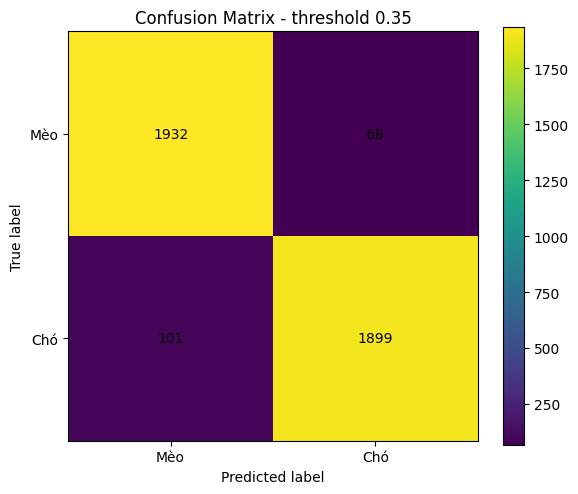

Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/test_metrics.json
Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/classification_report.csv
Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/classification_report.txt
Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/confusion_matrix.npy
Đã lưu: /content/drive/MyDrive/HOCSAU/output/main2/confusion_matrix.png


In [19]:
# ============================================================
# CELL 19: ĐÁNH GIÁ TEST SET VỚI THRESHOLD TỐI ƯU
# Đây là bộ metrics chính dùng cho báo cáo/app.
# ============================================================

metrics_opt, y_test_pred_opt = compute_binary_metrics(
    y_test_true,
    y_test_prob,
    threshold=recommended_threshold,
)

print("Metrics với threshold tối ưu từ validation:")
for key, value in metrics_opt.items():
    print(f"{key}: {value:.6f}")

# Lưu test_metrics.json giống format output oxford_pet_mobilenetv2.
test_metrics = {
    "threshold_recommended": float(recommended_threshold),
    "threshold_default": 0.5,
    "evaluate_metrics": {k: float(v) for k, v in test_eval.items()},
    "recommended_threshold_metrics": {k: float(v) for k, v in metrics_opt.items()},
    "threshold_0_50_metrics": {k: float(v) for k, v in metrics_05.items()},
}

with open(OUTPUT_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, ensure_ascii=False, indent=2)

pd.DataFrame([metrics_opt]).to_csv(OUTPUT_DIR / "test_metrics.csv", index=False, encoding="utf-8-sig")

report_opt_dict = classification_report(
    y_test_true,
    y_test_pred_opt,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
report_opt_text = classification_report(
    y_test_true,
    y_test_pred_opt,
    target_names=class_names,
    zero_division=0,
)

with open(OUTPUT_DIR / "classification_report.json", "w", encoding="utf-8") as f:
    json.dump(report_opt_dict, f, ensure_ascii=False, indent=2)

pd.DataFrame(report_opt_dict).transpose().to_csv(
    OUTPUT_DIR / "classification_report.csv",
    encoding="utf-8-sig",
)

with open(OUTPUT_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_opt_text)

print("\nClassification report threshold tối ưu:")
print(report_opt_text)

cm_opt = confusion_matrix(y_test_true, y_test_pred_opt)

np.save(OUTPUT_DIR / "confusion_matrix.npy", cm_opt)

pd.DataFrame(cm_opt, index=class_names, columns=class_names).to_csv(
    OUTPUT_DIR / "confusion_matrix.csv",
    encoding="utf-8-sig",
)

plt.figure(figsize=(6, 5))
plt.imshow(cm_opt)
plt.title(f"Confusion Matrix - threshold {recommended_threshold:.2f}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(len(class_names)), class_names_vi)
plt.yticks(range(len(class_names)), class_names_vi)
for i in range(cm_opt.shape[0]):
    for j in range(cm_opt.shape[1]):
        plt.text(j, i, str(cm_opt[i, j]), ha="center", va="center")
plt.colorbar()
plt.tight_layout()
cm_opt_plot_path = OUTPUT_DIR / "confusion_matrix.png"
plt.savefig(cm_opt_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu:", OUTPUT_DIR / "test_metrics.json")
print("Đã lưu:", OUTPUT_DIR / "classification_report.csv")
print("Đã lưu:", OUTPUT_DIR / "classification_report.txt")
print("Đã lưu:", OUTPUT_DIR / "confusion_matrix.npy")
print("Đã lưu:", cm_opt_plot_path)


In [20]:
# ============================================================
# CELL 20: LƯU CHI TIẾT DỰ ĐOÁN TEST SET
# ============================================================

prediction_df = pd.DataFrame({
    "file_path": test_file_paths,
    "true_label_index": y_test_true,
    "true_class": [class_names[i] for i in y_test_true],
    "true_class_vi": [class_names_vi[i] for i in y_test_true],
    "prob_cat": 1.0 - y_test_prob,
    "prob_dog": y_test_prob,
    "pred_label_0_50": y_test_pred_05,
    "pred_class_0_50": [class_names[i] for i in y_test_pred_05],
    "pred_class_vi_0_50": [class_names_vi[i] for i in y_test_pred_05],
    "correct_0_50": y_test_pred_05 == y_test_true,
    "pred_label_recommended": y_test_pred_opt,
    "pred_class_recommended": [class_names[i] for i in y_test_pred_opt],
    "pred_class_vi_recommended": [class_names_vi[i] for i in y_test_pred_opt],
    "correct_recommended": y_test_pred_opt == y_test_true,
})

prediction_df["confidence_recommended"] = np.where(
    prediction_df["pred_label_recommended"] == 1,
    prediction_df["prob_dog"],
    prediction_df["prob_cat"],
)
prediction_df["error_margin_recommended"] = np.abs(prediction_df["prob_dog"] - recommended_threshold)

prediction_path = OUTPUT_DIR / "test_predictions.csv"
prediction_df.to_csv(prediction_path, index=False, encoding="utf-8-sig")

display(prediction_df.head())
print("Đã lưu chi tiết dự đoán:", prediction_path)


,file_path,true_label_index,true_class,true_class_vi,prob_cat,prob_dog,pred_label_0_50,pred_class_0_50,pred_class_vi_0_50,correct_0_50,pred_label_recommended,pred_class_recommended,pred_class_vi_recommended,correct_recommended,confidence_recommended,error_margin_recommended
0,/content/drive/MyDrive/HOCSAU/data/dataset_com...,0,cats,Mèo,0.999915,8.526076e-05,0,cats,Mèo,True,0,cats,Mèo,True,0.999915,0.349915
1,/content/drive/MyDrive/HOCSAU/data/dataset_com...,0,cats,Mèo,0.999993,6.811024e-06,0,cats,Mèo,True,0,cats,Mèo,True,0.999993,0.349993
2,/content/drive/MyDrive/HOCSAU/data/dataset_com...,0,cats,Mèo,0.998714,1.285993e-03,0,cats,Mèo,True,0,cats,Mèo,True,0.998714,0.348714
3,/content/drive/MyDrive/HOCSAU/data/dataset_com...,0,cats,Mèo,0.981590,1.841035e-02,0,cats,Mèo,True,0,cats,Mèo,True,0.981590,0.331590
4,/content/drive/MyDrive/HOCSAU/data/dataset_com...,0,cats,Mèo,1.000000,6.323931e-08,0,cats,Mèo,True,0,cats,Mèo,True,1.000000,0.350000


Đã lưu chi tiết dự đoán: /content/drive/MyDrive/HOCSAU/output/main2/test_predictions.csv


In [21]:
# ============================================================
# CELL 21: VISUALIZE ẢNH DỰ ĐOÁN SAI VÀ ĐÚNG
# ============================================================


def plot_prediction_examples(df, title, output_path, max_images=12):
    df = df.head(max_images).copy()
    if len(df) == 0:
        print("Không có ảnh để vẽ:", title)
        return

    n = len(df)
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 4, rows * 4))

    for idx, row in enumerate(df.itertuples(), start=1):
        ax = plt.subplot(rows, cols, idx)
        try:
            img = Image.open(row.file_path).convert("RGB")
            plt.imshow(img)
        except Exception as e:
            plt.text(0.5, 0.5, "Không mở được ảnh", ha="center", va="center")

        plt.title(
            f"True: {row.true_class_vi}\nPred: {row.pred_class_vi_recommended}\n"
            f"dog={row.prob_dog:.3f}, conf={row.confidence_recommended:.3f}",
            fontsize=10,
        )
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Đã lưu:", output_path)

wrong_df = prediction_df[prediction_df["correct_recommended"] == False].sort_values(
    "confidence_recommended",
    ascending=False,
)
correct_df = prediction_df[prediction_df["correct_recommended"] == True].sort_values(
    "confidence_recommended",
    ascending=False,
)

plot_prediction_examples(
    wrong_df,
    title="Ảnh dự đoán sai có độ tin cậy cao nhất",
    output_path=OUTPUT_DIR / "wrong_samples.png",
    max_images=12,
)

plot_prediction_examples(
    correct_df,
    title="Ảnh dự đoán đúng có độ tin cậy cao nhất",
    output_path=OUTPUT_DIR / "correct_samples.png",
    max_images=12,
)

wrong_df.to_csv(OUTPUT_DIR / "wrong_predictions.csv", index=False, encoding="utf-8-sig")
correct_df.to_csv(OUTPUT_DIR / "correct_predictions.csv", index=False, encoding="utf-8-sig")

print("Số ảnh sai threshold tối ưu:", len(wrong_df))
print("Số ảnh đúng threshold tối ưu:", len(correct_df))


Output hidden; open in https://colab.research.google.com to view.

In [22]:
# ============================================================
# CELL 22: LƯU FILE THÔNG TIN CHO APP + TRAINING INFO
# App chỉ cần đọc app_model_info.json để biết model, threshold, input size.
# ============================================================

app_model_info = {
    "model_name": "cnn_cat_dog_main2",
    "task": "binary_cat_dog_classification",
    "model_path": str(BEST_MODEL_PATH),
    "latest_model_path": str(LATEST_MODEL_PATH),
    "final_model_path": str(FINAL_MODEL_PATH),
    "recommended_threshold": recommended_threshold,
    "default_threshold": 0.5,
    "img_size": list(IMG_SIZE),
    "class_names": class_names,
    "class_names_vi": class_names_vi,
    "class_mapping": {name: idx for idx, name in enumerate(class_names)},
    "positive_class": "dogs",
    "positive_class_index": class_names.index("dogs") if "dogs" in class_names else 1,
    "preprocess_note": "Ảnh đầu vào nên convert RGB và resize theo img_size. Không chia 255 trong app vì model đã có Rescaling(1./255).",
    "output_note": "Sigmoid output: prob_dog >= threshold là Chó, ngược lại là Mèo.",
    "test_metrics_threshold_0_50": metrics_05,
    "test_metrics_recommended_threshold": metrics_opt,
    "output_dir": str(OUTPUT_DIR),
    "history_csv": str(HISTORY_CSV_PATH),
    "test_predictions_csv": str(OUTPUT_DIR / "test_predictions.csv"),
    "classification_report_csv": str(OUTPUT_DIR / "classification_report.csv"),
    "confusion_matrix_png": str(OUTPUT_DIR / "confusion_matrix.png"),
}

with open(APP_MODEL_INFO_PATH, "w", encoding="utf-8") as f:
    json.dump(app_model_info, f, ensure_ascii=False, indent=2)

training_info = {
    "project_dir": str(PROJECT_DIR),
    "dataset_dir": str(DATASET_DIR),
    "output_dir": str(OUTPUT_DIR),
    "train_images": int(eda_summary["total_train"]),
    "test_images": int(eda_summary["total_test"]),
    "img_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "target_epochs": TARGET_EPOCHS,
    "epochs_logged": int(len(history_df)),
    "initial_learning_rate": INITIAL_LEARNING_RATE,
    "best_model_path": str(BEST_MODEL_PATH),
    "latest_model_path": str(LATEST_MODEL_PATH),
    "final_model_path": str(FINAL_MODEL_PATH),
    "recommended_threshold": recommended_threshold,
    "final_test_metrics": metrics_opt,
}

with open(TRAINING_INFO_PATH, "w", encoding="utf-8") as f:
    json.dump(training_info, f, ensure_ascii=False, indent=2)

print("Đã lưu app_model_info:", APP_MODEL_INFO_PATH)
print("Đã lưu training_info:", TRAINING_INFO_PATH)
print(json.dumps(app_model_info, ensure_ascii=False, indent=2))


Đã lưu app_model_info: /content/drive/MyDrive/HOCSAU/output/main2/app_model_info.json
Đã lưu training_info: /content/drive/MyDrive/HOCSAU/output/main2/training_info.json
{
  "model_name": "cnn_cat_dog_main2",
  "task": "binary_cat_dog_classification",
  "model_path": "/content/drive/MyDrive/HOCSAU/output/main2/best_cnn_cats_dogs_main2.keras",
  "latest_model_path": "/content/drive/MyDrive/HOCSAU/output/main2/latest_cnn_cats_dogs_main2.keras",
  "final_model_path": "/content/drive/MyDrive/HOCSAU/output/main2/final_cnn_cats_dogs_main2.keras",
  "recommended_threshold": 0.35000000000000003,
  "default_threshold": 0.5,
  "img_size": [
    150,
    150
  ],
  "class_names": [
    "cats",
    "dogs"
  ],
  "class_names_vi": [
    "Mèo",
    "Chó"
  ],
  "class_mapping": {
    "cats": 0,
    "dogs": 1
  },
  "positive_class": "dogs",
  "positive_class_index": 1,
  "preprocess_note": "Ảnh đầu vào nên convert RGB và resize theo img_size. Không chia 255 trong app vì model đã có Rescaling(1./255)

In [23]:
# ============================================================
# CELL 23: TẠO README TÓM TẮT OUTPUT MAIN2
# ============================================================

readme_text = f'''
MAIN2 - CNN v2 PHÂN LOẠI CHÓ/MÈO
============================================================

Project:
{PROJECT_DIR}

Dataset:
{DATASET_DIR}

Output folder:
{OUTPUT_DIR}

MODEL FILES
------------------------------------------------------------
Best model:
{BEST_MODEL_PATH}

Latest model:
{LATEST_MODEL_PATH}

Final model:
{FINAL_MODEL_PATH}

APP / CONFIG FILES
------------------------------------------------------------
App model info:
{APP_MODEL_INFO_PATH}

Class names:
{CLASS_NAMES_PATH}

Recommended threshold:
{THRESHOLD_PATH}

Model config:
{CONFIG_PATH}

Training info:
{TRAINING_INFO_PATH}

METRICS / REPORT FILES
------------------------------------------------------------
Training history:
{HISTORY_CSV_PATH}

Test metrics:
{OUTPUT_DIR / 'test_metrics.json'}

Test predictions:
{OUTPUT_DIR / 'test_predictions.csv'}

Confusion matrix:
{OUTPUT_DIR / 'confusion_matrix.npy'}
{OUTPUT_DIR / 'confusion_matrix.png'}

Classification report:
{OUTPUT_DIR / 'classification_report.csv'}
{OUTPUT_DIR / 'classification_report.txt'}

PLOTS / EDA
------------------------------------------------------------
{OUTPUT_DIR / 'eda_class_distribution.png'}
{OUTPUT_DIR / 'eda_sample_images.png'}
{OUTPUT_DIR / 'accuracy_curve.png'}
{OUTPUT_DIR / 'loss_curve.png'}
{OUTPUT_DIR / 'correct_samples.png'}
{OUTPUT_DIR / 'wrong_samples.png'}

APP PREPROCESS NOTE
------------------------------------------------------------
- App nên mở ảnh bằng PIL, convert('RGB'), resize về {IMG_SIZE}.
- Không chia pixel cho 255 trong app vì model đã có lớp Rescaling(1./255).
- Sigmoid output là xác suất dog.
- Nếu prob_dog >= recommended_threshold thì dự đoán Chó, ngược lại Mèo.
'''.strip()

readme_path = OUTPUT_DIR / "README_main2.txt"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print(readme_text)
print("\nĐã lưu README:", readme_path)


MAIN2 - CNN v2 PHÂN LOẠI CHÓ/MÈO

Project:
/content/drive/MyDrive/HOCSAU

Dataset:
/content/drive/MyDrive/HOCSAU/data/dataset_combined_main

Output folder:
/content/drive/MyDrive/HOCSAU/output/main2

MODEL FILES
------------------------------------------------------------
Best model:
/content/drive/MyDrive/HOCSAU/output/main2/best_cnn_cats_dogs_main2.keras

Latest model:
/content/drive/MyDrive/HOCSAU/output/main2/latest_cnn_cats_dogs_main2.keras

Final model:
/content/drive/MyDrive/HOCSAU/output/main2/final_cnn_cats_dogs_main2.keras

APP / CONFIG FILES
------------------------------------------------------------
App model info:
/content/drive/MyDrive/HOCSAU/output/main2/app_model_info.json

Class names:
/content/drive/MyDrive/HOCSAU/output/main2/class_names.json

Recommended threshold:
/content/drive/MyDrive/HOCSAU/output/main2/recommended_threshold.json

Model config:
/content/drive/MyDrive/HOCSAU/output/main2/model_config.json

Training info:
/content/drive/MyDrive/HOCSAU/output/main

## Ghi chú sau khi train

Sau khi notebook chạy xong, toàn bộ file output chính nằm trong:

```text
output/main2/
```

Các file cần dùng cho app:

```text
output/main2/best_cnn_cats_dogs_main2.keras
output/main2/app_model_info.json
output/main2/class_names.json
output/main2/recommended_threshold.json
```

Cấu trúc output của `main2` đã được làm phẳng để giống cách lưu của:

```text
output/oxford_pet_mobilenetv2/
```

Nếu app Flask/Streamlit đang load model từ `output/output_2/...`, hãy đổi sang đọc từ:

```text
output/main2/best_cnn_cats_dogs_main2.keras
```

hoặc đọc trực tiếp `output/main2/app_model_info.json`.
